Enter the 1st feature(comma separated):1,2,3,4
Enter the 2nd feature(comma separated):2,3,5,4
Regression line:y=0.80x+1.50
MAE=0.55
MSE=0.45
RMSE=0.67
R2=0.64


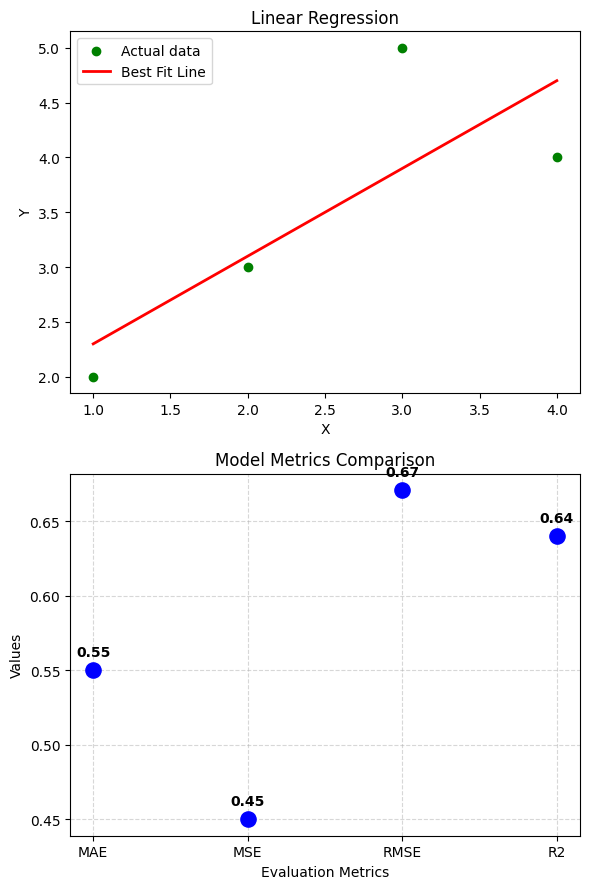

In [1]:
import matplotlib.pyplot as plt
x_text=input("Enter the 1st feature(comma separated):")
y_text=input("Enter the 2nd feature(comma separated):")
x=[float(i) for i in x_text.split(",")]
y=[float(i) for i in y_text.split(",")]
n=len(x)
sum_x=sum(x)
sum_y=sum(y)
sum_xy=sum(x[i]*y[i] for i in range(n))
sum_x2=sum(x[i]**2 for i in range(n))
m=(n*sum_xy-sum_x*sum_y)/(n*sum_x2-sum_x**2)
c=(sum_y-m*sum_x)/n
y_pred=[m*xi+c for xi in x]
errors=[y[i]-y_pred[i] for i in range(n)]
mae=sum(abs(e) for e in errors)/n
mse=sum(e**2 for e in errors)/n
rmse=mse**0.5
y_mean=sum_y/n
ss_total=sum((yi-y_mean)**2 for yi in y)
ss_residual=sum(e**2 for e in errors)
r2=1-(ss_residual/ss_total)
print(f"Regression line:y={m:.2f}x+{c:.2f}")
print(f"MAE={mae:.2f}")
print(f"MSE={mse:.2f}")
print(f"RMSE={rmse:.2f}")
print(f"R2={r2:.2f}")
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(6,9))
ax1.scatter(x,y,color="green",label="Actual data",zorder=3)
ax1.plot(x,y_pred,color="red",linewidth=2,label="Best Fit Line")
ax1.set_title("Linear Regression")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.legend()
labels=["MAE","MSE","RMSE","R2"]
values=[mae,mse,rmse,r2]
ax2.scatter(labels,values,color="blue",s=120,zorder=3)
for i,v in enumerate(values):
    ax2.annotate(f"{v:.2f}",(i,v),textcoords="offset points",xytext=(0,10),
                 ha="center",fontsize=10,fontweight="bold")
ax2.set_title("Model Metrics Comparison")
ax2.set_xlabel("Evaluation Metrics")
ax2.set_ylabel("Values")
ax2.grid(True,linestyle="--",alpha=0.5)
plt.tight_layout()
plt.show()